# Task 2: Chunking, Embedding & Indexing: Visualization & Showcase

**Branch:** `feat/sample-vector-store`

This notebook is a **report/showcase companion**, not the pipeline
itself, the actual Task 2 deliverable ("a script performing chunking,
embedding, and indexing") is `src/build_sample_index.py`, run via:

```bash
python -m src.build_sample_index
```

That script is the single, reproducible source of truth for
`vector_store_sample/`. This notebook exists to *visualize* what each
modular script does, one stage at a time, and to show the chunk-size
experimentation and justification the Task 2 brief asks for in the
report, none of that visual/exploratory work belongs inside the
production script itself.

## Running order of the modular scripts

| Order | Script | What it does | Run via |
|---|---|---|---|
| 1 | `src/preprocessing.py` | Clean & filter narratives (Task 1) | `notebooks/01_eda_preprocessing.ipynb` → produces `data/processed/filtered_complaints.csv` |
| 2 | `src/sampling.py` | Draw the proportional stratified sample | called by step 5, or standalone: `stratified_sample(df, n=12500)` |
| 3 | `src/chunking.py` | Split narratives into 500/50-char chunks | called by step 5, or standalone: `get_text_splitter()` + `chunk_dataframe(...)` |
| 4 | `src/embedding.py` | Embed chunks, build the ChromaDB collection | called by step 5, or standalone: `load_embedding_model()` + `embed_chunks(...)` + `build_chroma_store(...)` |
| 5 | `src/build_sample_index.py` | Orchestrates 2→3→4 in one deterministic run, writes `vector_store_sample/` + `build_manifest.json` | `python -m src.build_sample_index` |

Steps 2-4 are shown individually below purely to visualize each stage
in production, step 5 runs all three in sequence with a single command,
so there's no manual multi-step process to get out of sync.


In [1]:
import sys
sys.path.insert(0, "..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from src.sampling import stratified_sample, summarize_sample
from src.chunking import get_text_splitter, chunk_dataframe
from src.embedding import load_embedding_model, embed_chunks, build_chroma_store, EMBEDDING_MODEL_NAME

sns.set_style("whitegrid")
FILTERED_PATH = "../data/processed/filtered_complaints.csv"


c:\Users\AAM3\Desktop\rag_complaint_chatbot_\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Stage 1 (recap): the filtered dataset from Task 1

In [2]:
df = pd.read_csv(FILTERED_PATH)
print(f"{len(df):,} cleaned complaints")
df["product_category"].value_counts()


480,560 cleaned complaints


product_category
Credit Card        189333
Savings Account    155202
Money Transfer      98684
Personal Loan       37341
Name: count, dtype: int64

## Stage 2: Stratified sampling

`src/sampling.py`'s `stratified_sample()` draws a 12,500-complaint
sample **proportional** to each category's real share of the filtered
dataset, not an equal split. The chart below is the visual justification
for that choice: the real dataset is naturally imbalanced (~5:1 between
the largest and smallest category), and the sample preserves that
imbalance at 1/Nth scale rather than manufacturing artificial balance
that doesn't reflect CrediTrust's actual complaint volume.


In [3]:
SAMPLE_SIZE = 12_500
sample_df = stratified_sample(df, n=SAMPLE_SIZE, random_state=42)
print(f"{len(sample_df):,} complaints sampled")

full_counts = df["product_category"].value_counts(normalize=True) * 100
sample_counts = sample_df["product_category"].value_counts(normalize=True) * 100

comparison = pd.DataFrame({"full_dataset_%": full_counts, "sample_%": sample_counts}).round(1)
comparison


12,500 complaints sampled


,full_dataset_%,sample_%
product_category,,
Credit Card,39.4,39.4
Savings Account,32.3,32.3
Money Transfer,20.5,20.5
Personal Loan,7.8,7.8


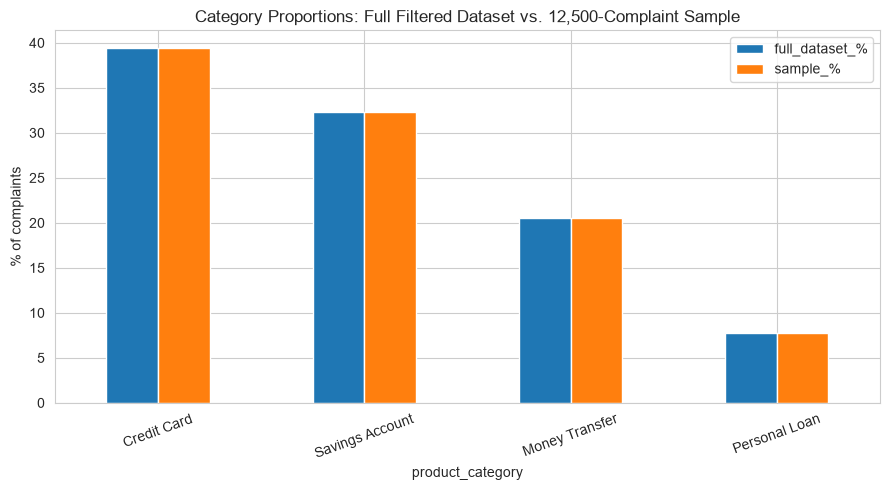

In [4]:
fig, ax = plt.subplots(figsize=(9, 5))
comparison.plot(kind="bar", ax=ax)
ax.set_ylabel("% of complaints")
ax.set_title("Category Proportions: Full Filtered Dataset vs. 12,500-Complaint Sample")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig("../data/processed/sample_vs_full_proportions.png", dpi=150)
plt.show()


## Stage 3: Chunking: parameter experimentation

The Task 2 brief asks us to experiment with `chunk_size`/`chunk_overlap`
and justify the final choice. Below, three candidate configurations are
run against the same sample and compared by resulting chunk count and
chunk-length distribution, before settling on the final 500/50 pair.

Note the final choice isn't a free parameter here in the way it might be
in a standalone project: 500/50 is fixed by the pre-built
`complaint_embeddings.parquet` spec that Tasks 3-4 use, so chunk
granularity stays consistent whether a query hits this Task 2 sample
index or the full Task 3/4 index. The comparison below shows *why* that
constraint is a reasonable one to have inherited, not just a rule
followed blindly.


In [5]:
candidates = [
    (250, 25),
    (500, 50),   # final choice
    (1000, 100),
]

comparison_rows = []
for chunk_size, chunk_overlap in candidates:
    splitter = get_text_splitter(chunk_size=chunk_size, chunk_overlap=chunk_overlap)
    records = chunk_dataframe(sample_df, text_column="cleaned_narrative", splitter=splitter)
    lengths = [len(r["chunk_text"]) for r in records]
    comparison_rows.append({
        "chunk_size": chunk_size,
        "chunk_overlap": chunk_overlap,
        "total_chunks": len(records),
        "avg_chunks_per_complaint": round(len(records) / len(sample_df), 2),
        "avg_chunk_length": round(np.mean(lengths), 1),
    })

chunk_comparison = pd.DataFrame(comparison_rows)
chunk_comparison


,chunk_size,chunk_overlap,total_chunks,avg_chunks_per_complaint,avg_chunk_length
0,250,25,41542,3.32,210.8
1,500,50,23316,1.87,370.9
2,1000,100,15606,1.25,541.6


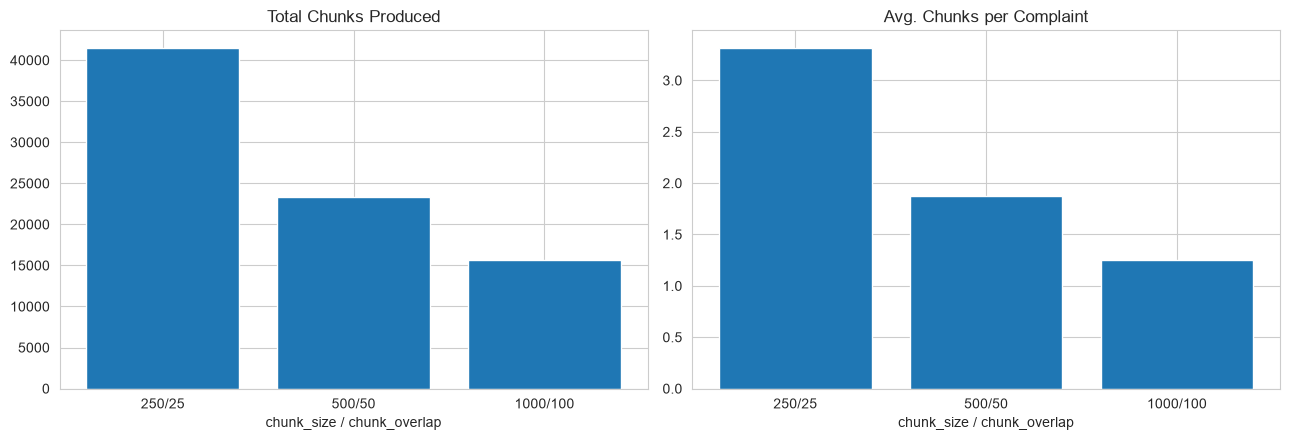

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].bar(
    [f"{r['chunk_size']}/{r['chunk_overlap']}" for r in comparison_rows],
    [r["total_chunks"] for r in comparison_rows],
)
axes[0].set_title("Total Chunks Produced")
axes[0].set_xlabel("chunk_size / chunk_overlap")

axes[1].bar(
    [f"{r['chunk_size']}/{r['chunk_overlap']}" for r in comparison_rows],
    [r["avg_chunks_per_complaint"] for r in comparison_rows],
)
axes[1].set_title("Avg. Chunks per Complaint")
axes[1].set_xlabel("chunk_size / chunk_overlap")

plt.tight_layout()
plt.savefig("../data/processed/chunk_size_comparison.png", dpi=150)
plt.show()


**Interpretation:** smaller chunks (250/25) produce ~2x more chunks per
complaint, more granular retrieval, but each chunk carries less
standalone context and the index grows accordingly. Larger chunks
(1000/100) approach a full narrative in one chunk (median narrative
length was 114 words ≈ 650-700 characters per the Task 1 EDA), which
risks diluting a chunk's embedding with multiple unrelated points in
one narrative. 500/50 sits in between, most short-to-medium complaints
fit in one or two chunks, longer ones split into a few topically
coherent pieces and matches the Tasks 3-4 pre-built store, so it's
both a reasonable standalone choice and a compatibility requirement.


## Stage 3 (final): chunk the sample with the chosen parameters

In [7]:
splitter = get_text_splitter(chunk_size=500, chunk_overlap=50)
chunk_records = chunk_dataframe(sample_df, text_column="cleaned_narrative", splitter=splitter)
print(f"{len(chunk_records):,} chunks from {len(sample_df):,} complaints")


23,316 chunks from 12,500 complaints


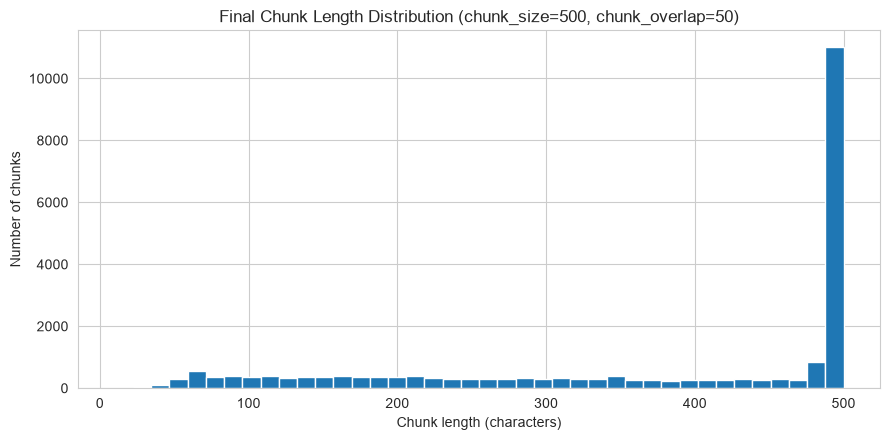

In [8]:
chunk_lengths = [len(r["chunk_text"]) for r in chunk_records]
plt.figure(figsize=(9, 4.5))
plt.hist(chunk_lengths, bins=40)
plt.xlabel("Chunk length (characters)")
plt.ylabel("Number of chunks")
plt.title("Final Chunk Length Distribution (chunk_size=500, chunk_overlap=50)")
plt.tight_layout()
plt.savefig("../data/processed/final_chunk_length_distribution.png", dpi=150)
plt.show()


In [9]:
# Example: a single complaint split into multiple chunks, to visualize
# how chunk_overlap keeps context from being lost at the boundary.
multi_chunk_id = next(
    (r["complaint_id"] for r in chunk_records if r["total_chunks"] > 1), None
)

if multi_chunk_id is None:
    print("No complaint in this sample produced more than one chunk -- "
          "every narrative fit within chunk_size=500 characters.")
else:
    example_chunks = [r for r in chunk_records if r["complaint_id"] == multi_chunk_id]
    for c in example_chunks:
        print(f"--- chunk {c['chunk_index']+1}/{c['total_chunks']} ---")
        print(c["chunk_text"][:200], "...\n")


--- chunk 1/5 ---
2020 apply credit card account comenity bank issue credit card handle account relate matter 2020 place call comenity inquire receive phone call accord fair credit report act victim identity theft come ...

--- chunk 2/5 ---
several supervisor state aware law could figure department send company supply credit consumer company employee credit approval department well verse fair credit report act identity theft know handle  ...

--- chunk 3/5 ---
freeze bureau report unable verify credit history statement false feel never call verify identity know wrong think would deny application would take care wrongdoing lift freeze 3 major credit bureau h ...

--- chunk 4/5 ---
pin number need ask send copy without pin number provide also enclose copy section credit report show view credit 2020 letter also state reapply 30 day lift freeze major credit report agency 3 major c ...

--- chunk 5/5 ---
reconsider without prejudice credit history actually verify access file request last w

## Stage 4: Embedding

Uses `sentence-transformers/all-MiniLM-L6-v2` via `src/embedding.py`.
This cell requires network access to download the model on first run
(not available in a sandboxed environment, run this notebook locally).

**Why this model:** 384-dimensional embeddings keep the full-scale index
(~1.37M chunks in Tasks 3-4) reasonably sized, and it runs fast enough on
CPU for both this batch job and per-query embedding at retrieval time in
`app.py`, at some accuracy cost vs. a larger model, an acceptable
tradeoff given complaint narratives are short and topically narrow (4
categories), not open-domain text.


In [10]:
from src.embedding import HF_TOKEN
print("Token loaded:", HF_TOKEN is not None)

Token loaded: True


In [11]:
model = load_embedding_model()

# Embed a manageable subset for visualization (embedding all ~23K chunks
# is what build_sample_index.py does; here we only need enough points to
# show separability). Cap at 150/category, using a plain per-category
# loop rather than groupby().apply() -- pandas' handling of the grouping
# column inside .apply() has changed across versions (and outright breaks
# with include_groups on newer ones), so a loop avoids that entirely.
chunk_records_df = pd.DataFrame(chunk_records)
per_category_cap = 150
frames = []
for category in chunk_records_df["product_category"].unique():
    subset = chunk_records_df[chunk_records_df["product_category"] == category]
    frames.append(subset.sample(min(len(subset), per_category_cap), random_state=42))
viz_sample = pd.concat(frames, ignore_index=True)

viz_records = viz_sample.to_dict("records")
viz_records = embed_chunks(model, viz_records)
print(f"Embedded {len(viz_records)} chunks for visualization, dim={len(viz_records[0]['embedding'])}")


Batches: 100%|██████████| 10/10 [00:08<00:00,  1.15it/s]

Embedded 600 chunks for visualization, dim=384


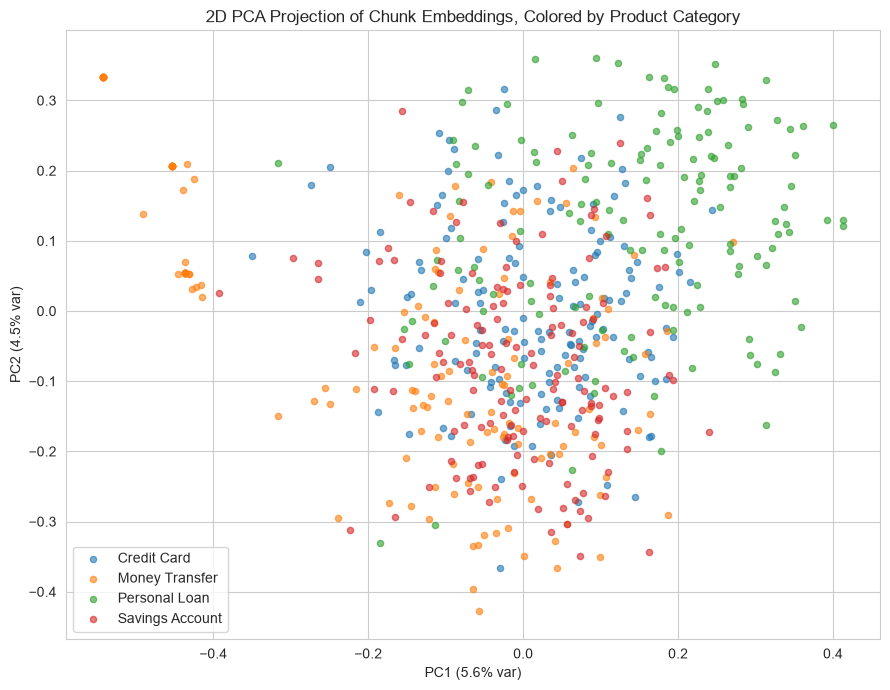

In [12]:
# 2D projection to visually check that chunks from the same product
# category embed near each other -- a sanity check on embedding quality
# before committing to building the full sample index.
embeddings = np.array([r["embedding"] for r in viz_records])
categories = [r["product_category"] for r in viz_records]

pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(embeddings)

plt.figure(figsize=(9, 7))
for cat in sorted(set(categories)):
    mask = [c == cat for c in categories]
    plt.scatter(coords[mask, 0], coords[mask, 1], label=cat, alpha=0.6, s=20)
plt.legend()
plt.title("2D PCA Projection of Chunk Embeddings, Colored by Product Category")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)")
plt.tight_layout()
plt.savefig("../data/processed/embedding_pca_by_category.png", dpi=150)
plt.show()


## Stage 5: Indexing & a live retrieval showcase

Builds a ChromaDB collection from the full chunk set and runs a real
similarity search against it, the same operation `app.py`'s retriever
performs at query time to showcase end-to-end retrieval quality before
moving on to Task 3.


In [13]:
full_chunk_records = embed_chunks(model, chunk_records)
collection = build_chroma_store(full_chunk_records, persist_dir="../vector_store_sample", collection_name="complaints_sample")
print(f"{collection.count():,} chunks indexed")


Batches: 100%|██████████| 365/365 [09:16<00:00,  1.52s/it]


23,316 chunks indexed


In [14]:
def showcase_query(question, top_k=3):
    query_embedding = model.encode(question, normalize_embeddings=True).tolist()
    results = collection.query(query_embeddings=[query_embedding], n_results=top_k,
                                include=["documents", "metadatas", "distances"])
    print(f"Q: {question}\n")
    for doc, meta, dist in zip(results["documents"][0], results["metadatas"][0], results["distances"][0]):
        print(f"  [{meta['product_category']}] similarity={1-dist:.3f}")
        print(f"  {doc[:180]}...\n")

showcase_query("why are customers unhappy with their credit cards")


Q: why are customers unhappy with their credit cards

  [Credit Card] similarity=0.271
  card high range understand company could put customer position purpose hurt someone credit file pathetic customer service someone never late give credit limit 5 month ago credit ca...

  [Credit Card] similarity=0.217
  card idea dont want credit score take another hit investigate escalate matter surprise didnt even send email confirmation payment ask several time accord thats possible dont unders...

  [Credit Card] similarity=0.124
  never receive card bill common occurrence get store credit card place like mall contact case involve call back admit fault fix error one want pay late fee even though wasnt fault l...



## Summary

This notebook visualized what `sampling.py` → `chunking.py` →
`embedding.py` do individually, and why 500/50 chunking and
`all-MiniLM-L6-v2` were chosen. For the actual, reproducible build of
`vector_store_sample/`, use the orchestrating script:

```bash
python -m src.build_sample_index
```

Next: Task 3 (RAG core logic), which retrieves against the full-scale
`vector_store_full/` index, not this sample store — see
`docs/WHY_A_CLEAN_REBUILD.md` for why that distinction matters.
